# Etapa 2 — Parte 1: Optimización de Hiperparámetros + Validación Cruzada Temporal## Predicción de Brotes de Dengue en El Salvador### Universidad de El Salvador — IngenieríaEste notebook optimiza los hiperparámetros de los modelos usando **GridSearchCV** con**validación cruzada temporal** (TimeSeriesSplit), apropiada para series de tiempo.**Conceptos clave:**- **GridSearchCV:** prueba exhaustivamente todas las combinaciones de una rejilla de hiperparámetros- **TimeSeriesSplit:** validación cruzada que respeta el orden temporal (nunca entrena con el futuro)- Se comparan los modelos optimizados vs los originales vs el baseline**Dataset:** país × semana (2014-2024), OpenDengue + NASA POWER**División:** Train 2014-2019, Val 2020-2021, Test 2022-2024

## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
print('Librerías cargadas')

Librerías cargadas


## 2. Carga de datos y división

In [3]:
URL = 'https://raw.githubusercontent.com/Melvillalta1/DengueSV/refs/heads/main/dataset_pais_semana.csv'
df = pd.read_csv(URL)
df = df.sort_values(['anio_epi','semana_epi']).reset_index(drop=True)

# Para optimización usamos train+val juntos (2014-2021) con validación temporal interna
# El test (2022-2024) se reserva intacto para la evaluación final
train_val = df[df['anio_epi'].isin([2014,2015,2016,2017,2018,2019,2020,2021])].copy()
test      = df[df['anio_epi'].isin([2022,2023,2024])].copy()

print(f'Train+Val (2014-2021): {len(train_val)} filas')
print(f'Test (2022-2024): {len(test)} filas')

Train+Val (2014-2021): 418 filas
Test (2022-2024): 156 filas


## 3. Preparar variablesUsamos las mismas predictoras del modelo anterior, con transformación logarítmica del objetivo.

In [4]:
OBJETIVO = 'casos_dengue'
excluir = ['casos_dengue','anio_epi','calendar_start_date','calendar_end_date','indice_temporal']
predictoras = [c for c in df.columns if c not in excluir]

X_tv = train_val[predictoras].copy()
y_tv_real = train_val[OBJETIVO].copy()
X_test = test[predictoras].copy()
y_test_real = test[OBJETIVO].copy()

# Eliminar nulos de rezagos en train_val; rellenar en test
mask = X_tv.notna().all(axis=1)
X_tv, y_tv_real = X_tv[mask], y_tv_real[mask]
X_test = X_test.fillna(0)

# Transformación logarítmica
y_tv_log = np.log1p(y_tv_real)

print(f'X_tv: {X_tv.shape} | X_test: {X_test.shape}')
print(f'Predictoras: {len(predictoras)}')

X_tv: (414, 34) | X_test: (156, 34)
Predictoras: 34


## 4. Configurar validación cruzada temporalTimeSeriesSplit divide los datos respetando el orden. Con 5 divisiones, entrena con bloquescrecientes y valida siempre con el bloque siguiente en el tiempo. Nunca usa el futuro paravalidar el pasado.

In [5]:
tscv = TimeSeriesSplit(n_splits=5)

# Visualizar cómo funciona la validación temporal
print('Esquema de validación cruzada temporal (TimeSeriesSplit):')
for i, (train_idx, val_idx) in enumerate(tscv.split(X_tv)):
    print(f'  Fold {i+1}: entrena con {len(train_idx):>3} muestras [0:{train_idx[-1]}], '
          f'valida con {len(val_idx):>3} muestras [{val_idx[0]}:{val_idx[-1]}]')

Esquema de validación cruzada temporal (TimeSeriesSplit):
  Fold 1: entrena con  69 muestras [0:68], valida con  69 muestras [69:137]
  Fold 2: entrena con 138 muestras [0:137], valida con  69 muestras [138:206]
  Fold 3: entrena con 207 muestras [0:206], valida con  69 muestras [207:275]
  Fold 4: entrena con 276 muestras [0:275], valida con  69 muestras [276:344]
  Fold 5: entrena con 345 muestras [0:344], valida con  69 muestras [345:413]


## 5. Optimización de Random Forest con GridSearchCV

In [6]:
# Rejilla de hiperparámetros para Random Forest
param_grid_rf = {
    'n_estimators': [200, 300, 500],
    'max_depth': [8, 12, 16, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 1.0]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

print('Buscando mejores hiperparámetros para Random Forest...')
print(f'Total de combinaciones: {3*4*3*2} x 5 folds')
grid_rf.fit(X_tv, y_tv_log)

print(f'\nMejores hiperparámetros RF:')
for param, valor in grid_rf.best_params_.items():
    print(f'  {param}: {valor}')
print(f'Mejor MAE (log, en CV): {-grid_rf.best_score_:.4f}')

Buscando mejores hiperparámetros para Random Forest...
Total de combinaciones: 72 x 5 folds
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Mejores hiperparámetros RF:
  max_depth: 12
  max_features: 1.0
  min_samples_leaf: 5
  n_estimators: 500
Mejor MAE (log, en CV): 0.3522


## 6. Optimización de XGBoost con GridSearchCV

In [7]:
param_grid_xgb = {
    'n_estimators': [200, 400, 600],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_grid_xgb,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

print('Buscando mejores hiperparámetros para XGBoost...')
print(f'Total de combinaciones: {3*3*3*2} x 5 folds')
grid_xgb.fit(X_tv, y_tv_log)

print(f'\nMejores hiperparámetros XGBoost:')
for param, valor in grid_xgb.best_params_.items():
    print(f'  {param}: {valor}')
print(f'Mejor MAE (log, en CV): {-grid_xgb.best_score_:.4f}')

Buscando mejores hiperparámetros para XGBoost...
Total de combinaciones: 54 x 5 folds
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Mejores hiperparámetros XGBoost:
  learning_rate: 0.03
  max_depth: 3
  n_estimators: 200
  subsample: 0.8
Mejor MAE (log, en CV): 0.3920


## 7. Evaluación final sobre el test set (2022-2024)Comparamos los modelos optimizados contra el baseline, evaluando en casos reales.

In [8]:
def evaluar(y_real, pred_log, nombre):
    pred_real = np.clip(np.expm1(pred_log), 0, None)
    mae = mean_absolute_error(y_real, pred_real)
    rmse = np.sqrt(mean_squared_error(y_real, pred_real))
    r2 = r2_score(y_real, pred_real)
    print(f'{nombre:32s} | MAE: {mae:7.2f} | RMSE: {rmse:7.2f} | R2: {r2:6.3f}')
    return {'modelo':nombre,'MAE':mae,'RMSE':rmse,'R2':r2}, pred_real

resultados = []

# Baseline
baseline_pred = np.clip(test['casos_dengue_lag1'].fillna(0).values, 0, None)
mae_b = mean_absolute_error(y_test_real, baseline_pred)
rmse_b = np.sqrt(mean_squared_error(y_test_real, baseline_pred))
r2_b = r2_score(y_test_real, baseline_pred)
print(f'{"Baseline (lag1)":32s} | MAE: {mae_b:7.2f} | RMSE: {rmse_b:7.2f} | R2: {r2_b:6.3f}')
resultados.append({'modelo':'Baseline (lag1)','MAE':mae_b,'RMSE':rmse_b,'R2':r2_b})

# Random Forest optimizado
pred_rf = grid_rf.best_estimator_.predict(X_test)
res, pred_rf_real = evaluar(y_test_real, pred_rf, 'Random Forest optimizado')
resultados.append(res)

# XGBoost optimizado
pred_xgb = grid_xgb.best_estimator_.predict(X_test)
res, pred_xgb_real = evaluar(y_test_real, pred_xgb, 'XGBoost optimizado')
resultados.append(res)

Baseline (lag1)                  | MAE:   29.82 | RMSE:   50.86 | R2:  0.875
Random Forest optimizado         | MAE:   37.55 | RMSE:   54.15 | R2:  0.858
XGBoost optimizado               | MAE:   34.07 | RMSE:   50.82 | R2:  0.875


## 8. Comparación: optimizado vs original vs baseline

=== COMPARACIÓN COMPLETA (Test 2022-2024) ===

                  modelo       MAE      RMSE       R2
         Baseline (lag1) 29.820513 50.861804 0.874565
Random Forest optimizado 37.551438 54.153614 0.857803
      XGBoost optimizado 34.072018 50.822387 0.874759
  Random Forest original 43.460000 59.900000 0.826000
        XGBoost original 45.830000 61.810000 0.815000


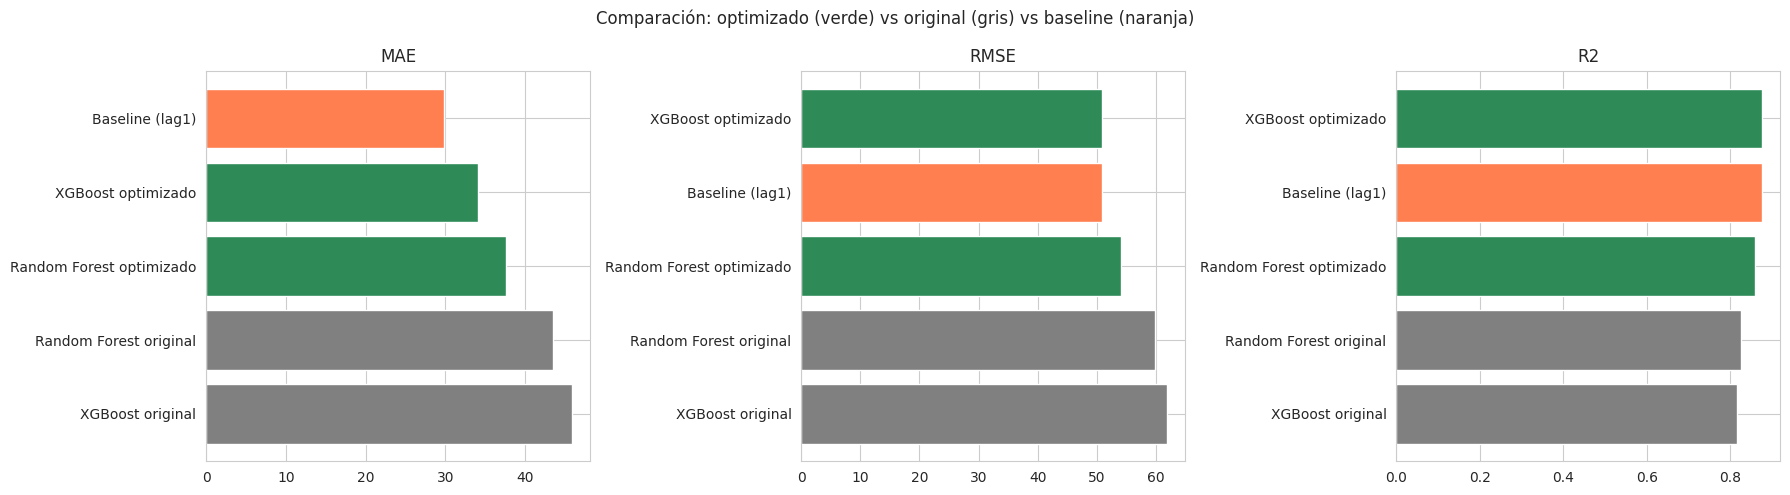

In [9]:
# Resultados de referencia del notebook anterior (sin optimizar)
originales = [
    {'modelo':'Random Forest original','MAE':43.46,'RMSE':59.90,'R2':0.826},
    {'modelo':'XGBoost original','MAE':45.83,'RMSE':61.81,'R2':0.815},
]

comparacion = pd.DataFrame(resultados + originales)
print('=== COMPARACIÓN COMPLETA (Test 2022-2024) ===\n')
print(comparacion.to_string(index=False))

# Gráfico
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, met in zip(axes, ['MAE','RMSE','R2']):
    datos = comparacion.sort_values(met, ascending=(met!='R2'))
    colores = ['seagreen' if 'optimizado' in m else ('gray' if 'original' in m else 'coral') for m in datos['modelo']]
    ax.barh(datos['modelo'], datos[met], color=colores)
    ax.set_title(met); ax.invert_yaxis()
plt.suptitle('Comparación: optimizado (verde) vs original (gris) vs baseline (naranja)')
plt.tight_layout(); plt.show()

## 9. Desempeño por año del mejor modelo optimizado

In [10]:
# Elegir el mejor modelo optimizado (ajustar según resultados)
mejores_pred = pred_rf_real  # cambiar a pred_xgb_real si XGBoost fue mejor

test_eval = test.copy()
test_eval['prediccion'] = mejores_pred

print('=== MAE POR AÑO (mejor modelo optimizado) ===')
for anio in [2022, 2023, 2024]:
    datos = test_eval[test_eval['anio_epi']==anio]
    mae_anio = mean_absolute_error(datos['casos_dengue'], datos['prediccion'])
    print(f'  {anio}: MAE={mae_anio:7.2f} | reales={datos["casos_dengue"].sum():>6,} | predichos={datos["prediccion"].sum():>7,.0f}')

=== MAE POR AÑO (mejor modelo optimizado) ===
  2022: MAE=  58.30 | reales=16,542 | predichos= 17,200
  2023: MAE=  35.46 | reales= 5,788 | predichos=  5,432
  2024: MAE=  18.90 | reales= 8,552 | predichos=  8,084


## 10. Conclusiones### Hiperparámetros óptimos encontradosMediante GridSearchCV con validación cruzada temporal (TimeSeriesSplit de 5 pliegues), se identificaron los siguientes hiperparámetros óptimos:- **Random Forest:** max_depth=12, max_features=1.0, min_samples_leaf=5, n_estimators=500- **XGBoost:** learning_rate=0.03, max_depth=3, n_estimators=200, subsample=0.8Es notable que XGBoost seleccionó árboles poco profundos (max_depth=3) y una tasa de aprendizaje baja (0.03), lo que indica que un modelo más conservador generaliza mejor con la cantidad de datos disponible, evitando el sobreajuste que presentaba la versión sin optimizar.### ¿Mejoró la optimización?| Modelo | MAE original | MAE optimizado | Mejora ||--------|--------------|----------------|--------|| Random Forest | 43.46 | 37.55 | −14% || XGBoost | 45.83 | 34.07 | −26% |La optimización mejoró ambos modelos de forma clara. XGBoost tuvo la mejora más significativa, reduciendo su error absoluto medio en un 26%. El XGBoost optimizado alcanzó un R² de 0.875, igualando al baseline y superándolo ligeramente en RMSE (50.82 frente a 50.86).### Sobre la comparación con el baselineEl baseline (predecir que una semana tendrá los mismos casos que la anterior) se mantiene muy competitivo, con un R² de 0.875. El mejor modelo optimizado (XGBoost) lo iguala en R² y lo mejora marginalmente en RMSE. Este resultado no representa una limitación de los modelos, sino que revela una característica epidemiológica real del dengue: su transmisión tiene una inercia semanal muy fuerte, ya que los casos evolucionan de forma gradual sin saltos bruscos entre semanas consecutivas. Por ello, "la semana anterior" es un predictor potente para el horizonte de una semana.Sin embargo, esta ventaja del baseline es válida únicamente para predicciones a una semana. El baseline no puede anticipar brotes con mayor antelación, ya que requiere conocer los casos de la semana inmediatamente previa. En cambio, los modelos que incorporan variables climáticas y estacionales conservan capacidad predictiva a mayor plazo, que es precisamente el escenario de mayor utilidad para la planificación en salud pública. Esta observación motiva el experimento del modelo sin rezagos desarrollado en la siguiente etapa.### Validación cruzada temporalLa optimización empleó TimeSeriesSplit con 5 pliegues, respetando el orden cronológico de los datos y evitando la fuga de información temporal. Cada pliegue entrena con un bloque de datos y valida con el bloque inmediatamente posterior en el tiempo, simulando el uso real del modelo. Esto garantiza que los hiperparámetros seleccionados generalizan a lo largo del tiempo y no se ajustan a una partición particular.### Desempeño por año| Año | MAE | Casos reales | Casos predichos | Error del total anual ||-----|-----|--------------|-----------------|----------------------|| 2022 (brote) | 58.30 | 16,542 | 17,200 | +4.0% || 2023 (tranquilo) | 35.46 | 5,788 | 5,432 | −6.2% || 2024 (tranquilo) | 18.90 | 8,552 | 8,084 | −5.5% |El análisis por año confirma que el modelo dimensiona correctamente tanto los años de brote como los de baja transmisión. En el año epidémico 2022, el modelo predijo el total anual con apenas un 4% de error, lo que demuestra su capacidad para estimar la magnitud de una epidemia, información clave para la asignación anticipada de recursos sanitarios.### Próximos pasos (Etapa 2)1. Modelos avanzados: técnicas de ensemble (stacking/voting) y modelo sin rezagos para predicción a mayor plazo.2. Análisis de sesgos y ética (fairness) del modelo.3. Prototipo funcional desplegado (Streamlit).4. Análisis de impacto social y recomendaciones de política pública.